In [ ]:

import numpy as np
import matplotlib.pyplot as plt


def plot_learning_curve(x, ep_actor_loss,ep_critic_loss,ep_value_loss,filename,plt_dpi, save_plot=True,plot_mod=True):
  if plot_mod==True:
    avg_x = [np.mean(x[np.max([0, i - 100]):i]) for i in range(len(x))]
    plt.figure(dpi=plt_dpi)
    # plt.title('Learning Curve')
    # plt.plot(range(len(x)), x, label='score', alpha=0.3)
    # plt.plot(range(len(avg_x)), avg_x, label='average score')
    # plt.xlabel('Episode')
    # plt.ylabel('Score')
    # plt.legend()
    # plt.grid()

    ind1=np.argwhere(x>0)[:,0]
    ind2=np.argwhere(x<=0)[:,0]
    if len(ind1)>0:
      plt.bar(ind1,x[ind1,], color='g')
    if len(ind2)>0:
      plt.bar(ind2,x[ind2,], color='r')
    plt.title('Mean Reward')
    # ax0.set_ylim(-10,10)
    plt.plot(avg_x,linewidth=4.0,color='b')

    fig, (ax1, ax2, ax3)  = plt.subplots(1, 3,figsize=(15, 3),dpi=plt_dpi, sharey='row')


    ax1.set_title('Actor Loss')
    # ax1.set_ylim(-20,20)
    ax1.plot(ep_actor_loss)

    ax2.set_title('Critic Loss')
    # ax2.set_ylim(0,65)
    ax2.plot(ep_critic_loss)

    ax3.set_title('Value Loss')
    # ax3.set_ylim(-20,20)
    ax3.plot(ep_value_loss)

    plt.show()


    if save_plot:
        plt.savefig(filename + '.png')
    plt.show()

  else:
    avg_x = [np.mean(x[np.max([0, i - 100]):i]) for i in range(len(x))]
    plt.figure(dpi=plt_dpi)

    ind1=np.argwhere(x>0)[:,0]
    ind2=np.argwhere(x<=0)[:,0]
    if len(ind1)>0:
      plt.bar(ind1,x[ind1,], color='g')
    if len(ind2)>0:
      plt.bar(ind2,x[ind2,], color='r')
    plt.title('Mean Reward')
    # ax0.set_ylim(-10,10)
    plt.plot(avg_x,linewidth=4.0,color='b')

    plt.figure(dpi=plt_dpi)
    plt.title('Actor Loss')
    # ax1.set_ylim(-20,20)
    plt.plot(ep_actor_loss)

    plt.title('Critic Loss')
    # ax2.set_ylim(0,65)
    plt.plot(ep_critic_loss)

    plt.title('Value Loss')
    # ax3.set_ylim(-20,20)
    plt.plot(ep_value_loss)

    plt.show()


In [ ]:
max_episode = 20000


gamma = 0.99
alpha = 3e-4
beta = 3e-4
fc1_dim = 1024
fc2_dim = 512
fc3_dim = 256

memory_size = 1000000
batch_size = 256
tau = 0.005
update_period = 2
reward_scale = 2.
warmup = 1000
reparam_noise_lim = 1e-6
play = False
load_checkpoint = False
gpu_to_cpu = False


## Run SAC
please set Key=Train for training and Test for testing function

In [ ]:
Key = "Train" #@param {type:"string"}

In [ ]:
step_env_plot = "Off" #@param {type:"string"}

In [ ]:
episode_env_plot = "Off" #@param {type:"string"}

In [ ]:
# !pip install keyboard

# import keyboard

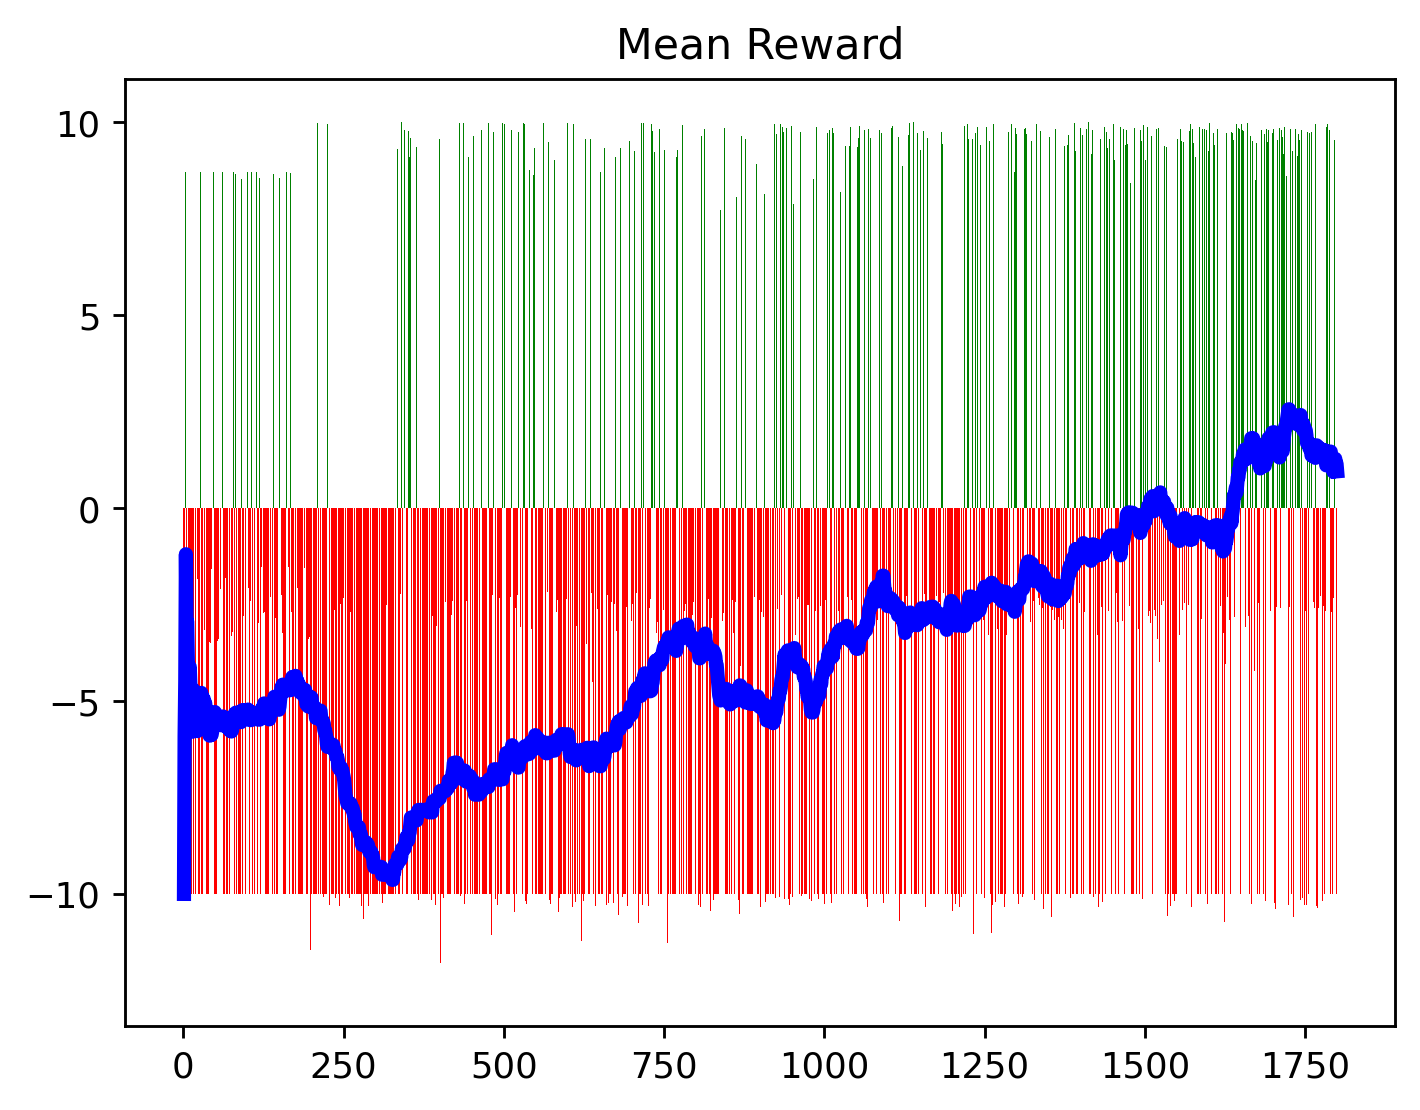

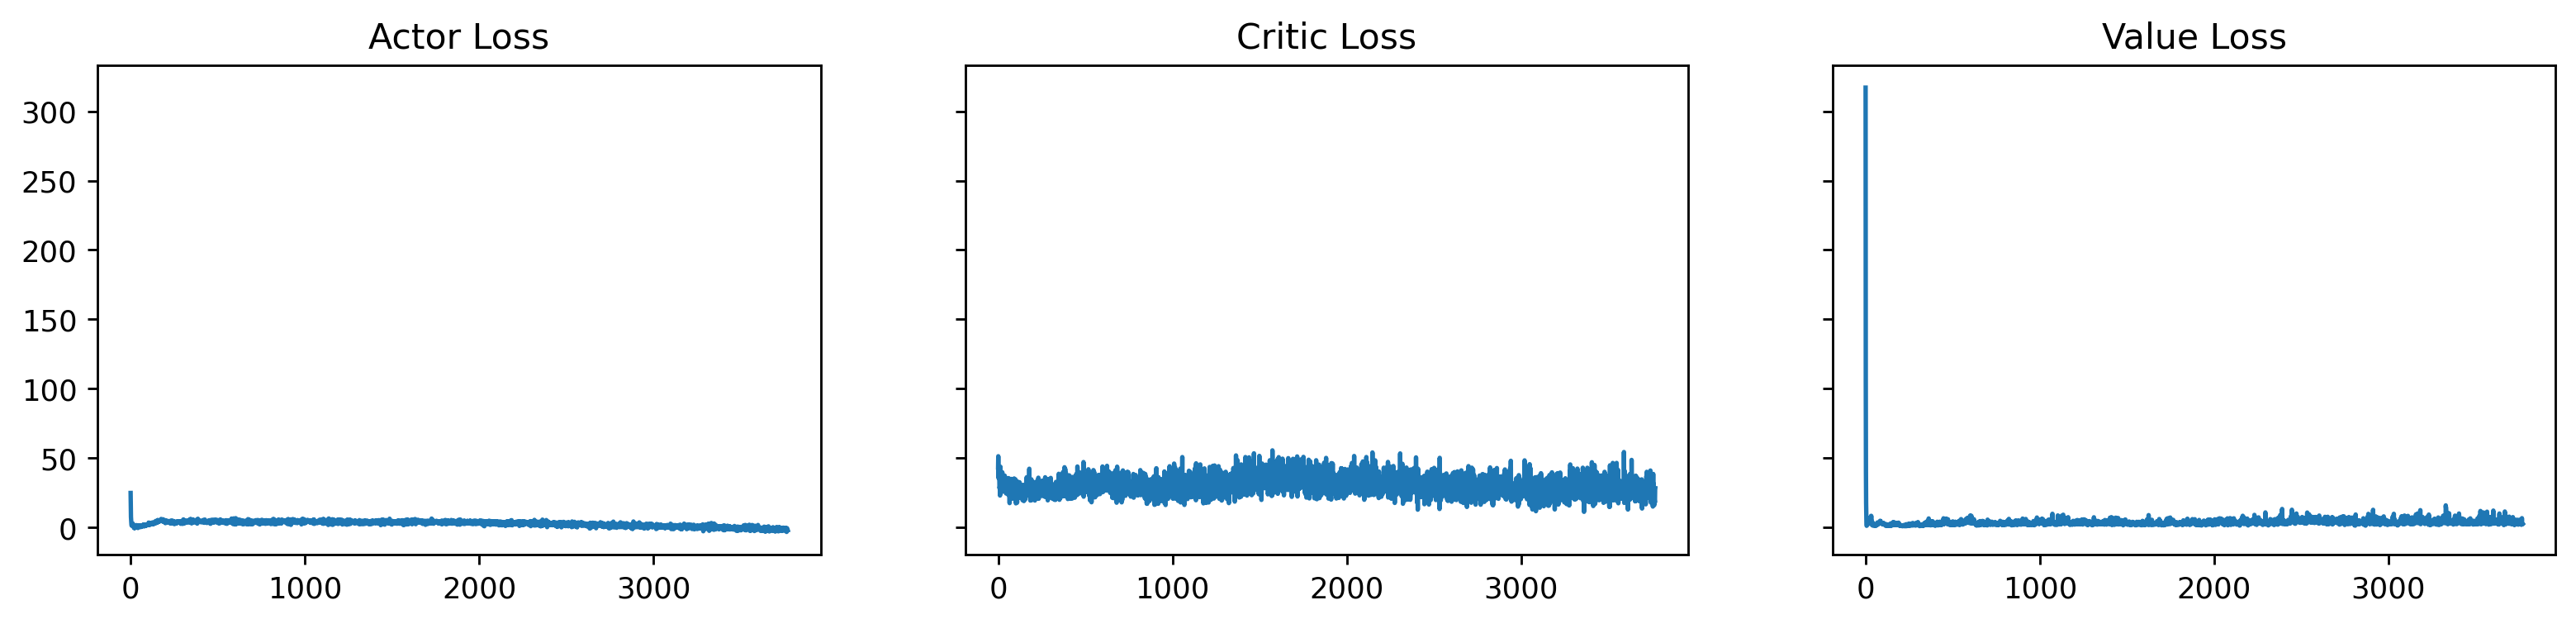

<Figure size 640x480 with 0 Axes>

| Episode:   1801 | Reward:       9.99 | Best score:       2.56 | Avg Reward       0.75 | Learning inter:       4777 |  Result:Successfull |  Ending step:         5
| Episode:   1802 | Reward:       9.95 | Best score:       2.56 | Avg Reward       0.95 | Learning inter:       4781 |  Result:Successfull |  Ending step:         4
| Episode:   1803 | Reward:      -2.13 | Best score:       2.56 | Avg Reward       1.02 | Learning inter:       4785 |  Result:Backward    |  Ending step:         4
| Episode:   1804 | Reward:       9.97 | Best score:       2.56 | Avg Reward       1.22 | Learning inter:       4788 |  Result:Successfull |  Ending step:         3
| Episode:   1805 | Reward:      -2.29 | Best score:       2.56 | Avg Reward       1.22 | Learning inter:       4790 |  Result:Backward    |  Ending step:         2
| Episode:   1806 | Reward:      -2.09 | Best score:       2.56 | Avg Reward       1.23 | Learning inter:       4793 |  Result:Backward    |  Ending step:         3
| Episode:

In [ ]:

if Key=="Train":

  env.dt=0.1
  max_step=10
  env.max_step=max_step
  env.freq=0.8
  ckpt_dir="/content/Microbot_Agent"
  if os.path.isdir(ckpt_dir)==0:
    os.mkdir(ckpt_dir)
  agent = Agent(gamma=gamma, alpha=alpha, beta=beta, state_dims=env.observation_space.shape,
              action_dims=env.action_space.shape, max_action=env.action_space.high[0],
              fc1_dim=fc1_dim, fc2_dim=fc2_dim,fc3_dim=fc3_dim, memory_size=memory_size,
              batch_size=batch_size, tau=tau, update_period=update_period,
              reward_scale=reward_scale, warmup=warmup, reparam_noise_lim=reparam_noise_lim,
              name='SAC_'+'Nemat', ckpt_dir=ckpt_dir)

  rewards, avg_rewards = [], []
  best_reward = -np.inf

  # if play:
  #   # env.render(mode='human') (cannot render in colab)
  #   pass

  # if load_checkpoint:
  #   agent.load_model(gpu_to_cpu=gpu_to_cpu)
  i_episode=-1

  env.max_episode=max_episode
  rew0=0
  dtheta=[]
  ep_actor_loss=[]
  ep_critic_loss=[]
  ep_value_loss=[]
  for episode in range(max_episode):
    env.episode=episode

    i_episode=i_episode+1
    # observation = env.reset()
    state, reward, done,target_cart=env.reset()

    env.state=state
    done = False
    ep_reward = rew0
    rew0=0
    # path=np.ndarray((max_step+1,3))

    [xs,ys]=pol2cart(env.rm, state[0])
    phis=0
    env.start_cart=[xs,ys,phis]
    env.start=state
    i_step=0
    # path[i_step,]=env.start_cart
    #step starting
    env.time=-1
    done=0

    if episode_env_plot=="on" :
      # env.path=path[0:i_step+1,]
      env.render()
    dth=0

    step_actor_loss=[]
    step_critic_loss=[]
    step_value_loss=[]
    actor_loss,critic_loss,value_loss=[],[] ,[]
    while done==0 and i_step<max_step:
        env.time=env.time+dt
        env.i_step=i_step
        # if np.random.rand(1)<0.05:
        #   action = np.array(np.random.uniform(-1,1,num_actions))
        # else:
        action = agent.choose_action(state, deterministic=False, reparameterize=False)
        next_state, reward, done ,microbot, info= env.step(action)
        env.microbot=microbot
        ep_reward += reward
        agent.store_transition(state, action, reward, next_state, done)
        actor_loss,critic_loss,value_loss=agent.learn()
        step_actor_loss=np.append(step_actor_loss,actor_loss)
        step_critic_loss=np.append(step_critic_loss,critic_loss)
        step_value_loss=np.append(step_value_loss,value_loss)

        state = next_state
        env.state = state
        env.action=action
        env.target_cart=target_cart
        [x,y]=pol2cart(env.rm,state[0])
        phi=0
        # path[i_step,]=[x,y,phi]
        env.microbot.P=[x,y,0,1]
        env.microbot.th=state[0]
        dth=np.append(dth,np.rad2deg(state[2]))
        i_step=i_step+1

        # env.path=path[0:i_step,]

        if step_env_plot=="On" :
          clear_output(wait=0.005)
          env.render()
    if episode_env_plot=="On" :
      clear_output(wait=0.005)
      env.render()
    #step ending

    dtheta=np.append(dtheta,np.mean(dth))
    # clear_output()
    # fig =plt.figure(figsize=(15,5))
    # plt.plot(dtheta)
    # plt.ylim([-10,10])
    # plt.grid()
    # plt.show()

    rewards=np.append(rewards,ep_reward)
    avg_reward = np.mean(rewards[-100:])
    avg_rewards.append(avg_reward)
    if agent.learn_iter >= agent.warmup and agent.learn_iter >= agent.batch_size :
      ep_actor_loss=np.append(ep_actor_loss,step_actor_loss)
      ep_critic_loss=np.append(ep_critic_loss,step_critic_loss)
      ep_value_loss=np.append(ep_value_loss,step_value_loss)
    if done==0:
      result='Failed      '
    elif done==1:
      result='Successfull '
    elif done==2:
      result='Out of range'
    elif done==3:
      result='Backward    '


    print(f'| Episode: {episode:6.0f} | Reward: {reward:10.2f} | Best score: {best_reward:10.2f} | '
          f'Avg Reward {avg_reward:10.2f} | Learning inter: {agent.learn_iter:10.0f} |  Result:{result}|  Ending step:{i_step:10.0f}')

    if avg_reward > best_reward:
        best_reward = avg_reward
        agent.save_model()
  # env.close()


    if episode%100==0:
      clear_output()
      plot_learning_curve(rewards,ep_actor_loss,ep_critic_loss,ep_value_loss, agent.full_path,plt_dpi=256,plot_mod=True)

  # if not play:
  #     plot_learning_curve(scores, agent.full_path)

#Plotting the learning performance diagram with higher resolution




In [ ]:

if Key=="Train":
  plot_learning_curve(rewards,ep_actor_loss,ep_critic_loss,ep_value_loss, agent.full_path,plt_dpi=1000,plot_mod=False)


#save the trained network in rar file

In [ ]:
if Key=="Train":
  !rar a "Microbot_Agent.rar" "Microbot_Agent/"

#Download the rar file

In [ ]:
from google.colab import files
if Key=="Train":
  files.download("Microbot_Agent.rar")